In [222]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.stats import f_oneway

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [223]:
# LOAD DATASET
df = pd.read_csv("BNPL_Dataset.csv")
df.head()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk



===== MISSING VALUES =====

user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64

===== CLASS DISTRIBUTION =====

default_flag
0    6305
1    4040
Name: count, dtype: int64

===== CLASS PERCENTAGE =====

default_flag
0    60.947318
1    39.052682
Name: proportion, dtype: float64


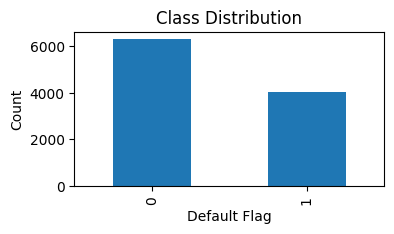

In [224]:
# BASIC DATA CLEANING/ EDA
# Remove duplicates
df.drop_duplicates(inplace=True)

# Missing values
print("\n===== MISSING VALUES =====\n")
print(df.isnull().sum())


# CHECK CLASS IMBALANCE
print("\n===== CLASS DISTRIBUTION =====\n")

print(df['default_flag'].value_counts())

print("\n===== CLASS PERCENTAGE =====\n")

print(df['default_flag'].value_counts(normalize=True) * 100)

# Visualization

plt.figure(figsize=(4,2))
df['default_flag'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Default Flag")
plt.ylabel("Count")
plt.show()

In [225]:
# FEATURE ENGINEERING
# Purchase-to-Income Ratio
df['purchase_income_ratio'] = (
    df['purchase_amount'] / df['monthly_income']
)

# Installment Burden
df['installment_burden'] = (
    (df['purchase_amount'] / df['bnpl_installments'])
    / df['monthly_income']
)

In [226]:
# ENCODE CATEGORICAL VARIABLES
categorical_cols = [
    'employment_type',
    'product_category',
    'location'
]

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

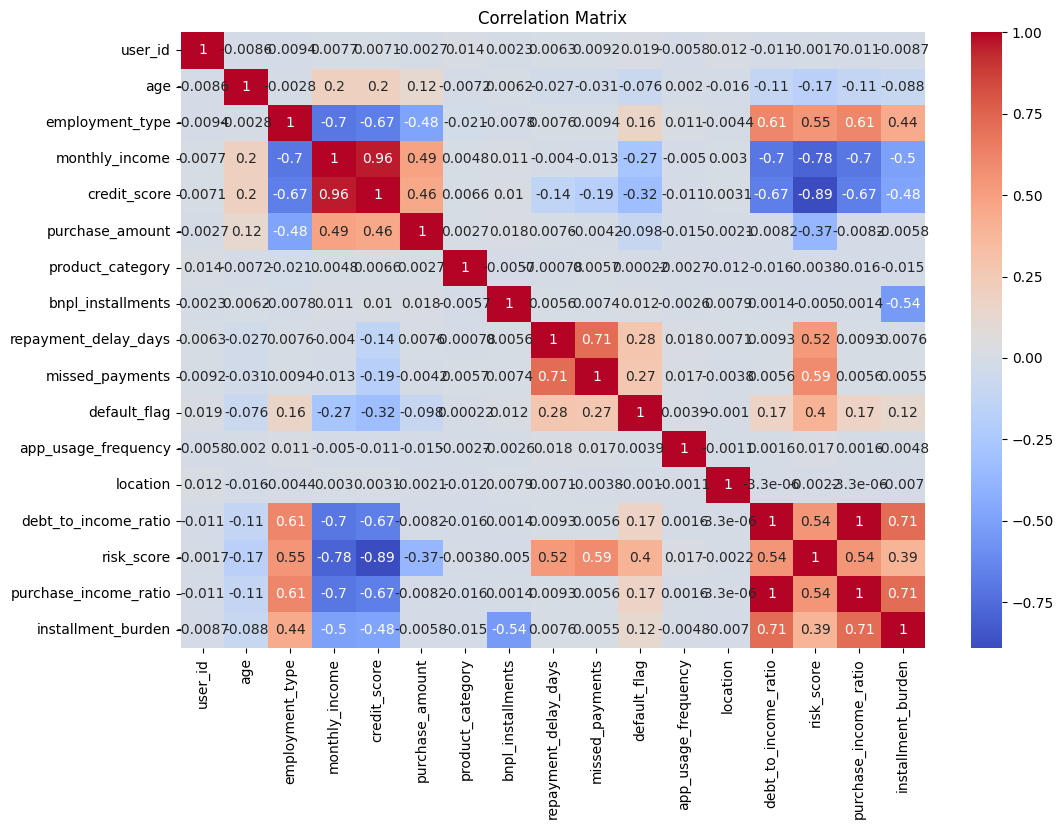

In [227]:
# CORRELATION MATRIX
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [228]:
# FEATURE SELECTION
X = df[
    [
        'age',
        'employment_type',
        'monthly_income',
        'credit_score',
        'purchase_amount',
        'product_category',
        'bnpl_installments',
        'app_usage_frequency',
        'location',
        'debt_to_income_ratio',
        'purchase_income_ratio',
        'installment_burden'
    ]
]

# Target Variable
y = df['default_flag']

In [229]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [230]:
# STANDARD SCALING
# ONLY FOR LOGISTIC REGRESSION
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TRAINING MODLS WITH CLASS IMBALANCE HANDLING
# LOGISTIC REGRESSION

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

# RANDOM FOREST

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# XGBOOST

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [231]:
# PROBABILITY OF DEFAULT (PD)

log_pd = log_model.predict_proba(X_test_scaled)[:, 1]
rf_pd = rf_model.predict_proba(X_test)[:, 1]
xgb_pd = xgb_model.predict_proba(X_test)[:, 1]

print("\n===== SAMPLE PROBABILITY OF DEFAULT =====\n")

print("Logistic Regression PD (first 5):", log_pd[:5])
print("Random Forest PD (first 5):", rf_pd[:5])
print("XGBoost PD (first 5):", xgb_pd[:5])

print("\n===== PD SUMMARY =====\n")

print("Logistic PD Mean:", np.mean(log_pd))
print("Random Forest PD Mean:", np.mean(rf_pd))
print("XGBoost PD Mean:", np.mean(xgb_pd))


===== SAMPLE PROBABILITY OF DEFAULT =====

Logistic Regression PD (first 5): [0.70490009 0.52773001 0.04415658 0.66101873 0.7150511 ]
Random Forest PD (first 5): [0.46  0.435 0.035 0.38  0.7  ]
XGBoost PD (first 5): [0.5253364  0.52369225 0.01696023 0.34620124 0.5515328 ]

===== PD SUMMARY =====

Logistic PD Mean: 0.4772919202360144
Random Forest PD Mean: 0.38196955050749154
XGBoost PD Mean: 0.38719755


In [232]:
# MODEL EVALUATION FUNCTION

def evaluate_model(model_name, y_test, predictions):

    print(f"\n========== {model_name} ==========\n")
    print("Accuracy:",
          round(accuracy_score(y_test, predictions), 4))
    print("Precision:",
          round(precision_score(y_test, predictions), 4))
    print("Recall:",
          round(recall_score(y_test, predictions), 4))
    print("F1 Score:",
          round(f1_score(y_test, predictions), 4))
    print("ROC-AUC Score:",
          round(roc_auc_score(y_test, predictions), 4))
    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, predictions))
    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions))

In [233]:
# EVALUATE MODELS

evaluate_model("Logistic Regression",y_test,log_pred)

evaluate_model("Random Forest",y_test,rf_pred)

evaluate_model("XGBoost",y_test,xgb_pred)


========== Logistic Regression ==========

Accuracy: 0.6443
Precision: 0.5331
Recall: 0.7166
F1 Score: 0.6114
ROC-AUC Score: 0.6573

Confusion Matrix:

[[754 507]
 [229 579]]

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.60      0.67      1261
           1       0.53      0.72      0.61       808

    accuracy                           0.64      2069
   macro avg       0.65      0.66      0.64      2069
weighted avg       0.68      0.64      0.65      2069


========== Random Forest ==========

Accuracy: 0.6365
Precision: 0.5426
Recall: 0.4418
F1 Score: 0.487
ROC-AUC Score: 0.6016

Confusion Matrix:

[[960 301]
 [451 357]]

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.76      0.72      1261
           1       0.54      0.44      0.49       808

    accuracy                           0.64      2069
   macro avg       0.61      0.60      0.60      2069
weight

In [234]:
# MODEL COMPARISON TABLE

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_pd),
        roc_auc_score(y_test, rf_pd),
        roc_auc_score(y_test, xgb_pd)
    ]
})

print("\n===== MODEL COMPARISON TABLE =====\n")
print(model_comparison.sort_values(by="ROC-AUC", ascending=False))


===== MODEL COMPARISON TABLE =====

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.644273   0.533149  0.716584  0.611404  0.708903
2              XGBoost  0.637506   0.540616  0.477723  0.507227  0.701916
1        Random Forest  0.636539   0.542553  0.441832  0.487040  0.688874



===== FEATURE IMPORTANCE =====

                  Feature  Importance
3            credit_score    0.186247
2          monthly_income    0.130850
7     app_usage_frequency    0.107088
9    debt_to_income_ratio    0.105458
10  purchase_income_ratio    0.102289
11     installment_burden    0.100710
0                     age    0.085077
4         purchase_amount    0.051956
8                location    0.043790
5        product_category    0.039153
1         employment_type    0.025790
6       bnpl_installments    0.021592


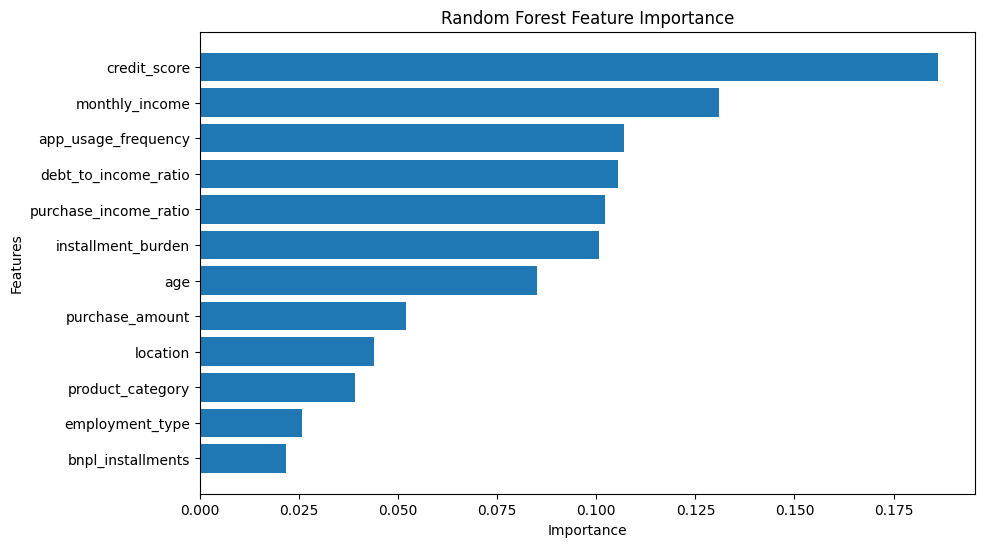

In [235]:
# FEATURE IMPORTANCE
# RANDOM FOREST
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n===== FEATURE IMPORTANCE =====\n")
print(importance_df)

# Visualization

plt.figure(figsize=(10,6))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [236]:
# CREATE REPAYMENT SUCCESS VARIABLE

df['log_installment_burden'] = np.log1p(df['installment_burden'])

# Repayment Success Definition:
# - Non-default customer
# - Delay <= 5 days
# - Missed payments < 3

df['repayment_success'] = (
    (df['default_flag'] == 0) &
    (df['repayment_delay_days'] <= 5) &
    (df['missed_payments'] < 3)
).astype(int)

In [237]:
installment_analysis = df.groupby(
    'bnpl_installments'
).agg(

    total_customers=('user_id', 'count'),

    # CORE VARIABLE (LOG BURDEN)
    avg_installment_burden=('log_installment_burden', 'mean'),

    # RISK OUTCOMES
    default_rate=('default_flag', 'mean'),
    avg_repayment_delay=('repayment_delay_days', 'mean'),
    avg_missed_payments=('missed_payments', 'mean'),

    # BEHAVIOR OUTCOME
    repayment_success_rate=('repayment_success', 'mean')
).reset_index()

# convert to %
installment_analysis['default_rate'] *= 100
installment_analysis['repayment_success_rate'] *= 100

In [238]:
# RISK SCORE (DECISION METRIC)

installment_analysis['risk_score'] = (
    installment_analysis['repayment_success_rate'] /
    (installment_analysis['default_rate'] + 1)
)

best_plan = installment_analysis.sort_values(
    by='risk_score',
    ascending=False
).iloc[0]

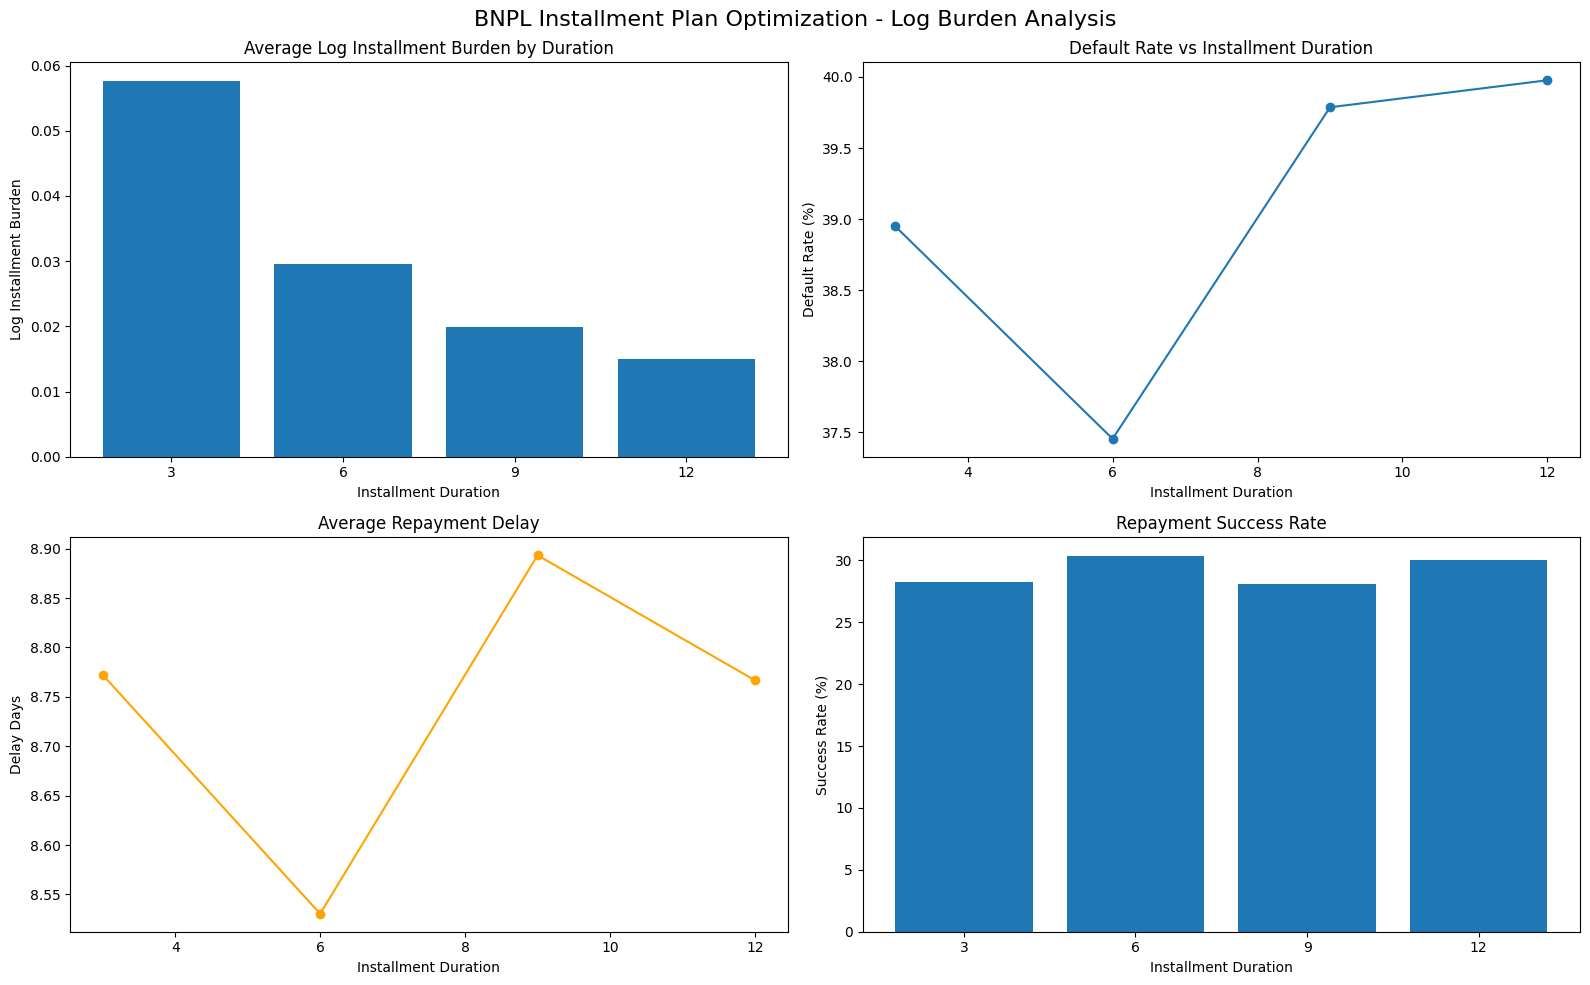

In [239]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# 1. LOG BURDEN
axes[0,0].bar(
    installment_analysis['bnpl_installments'].astype(str),
    installment_analysis['avg_installment_burden']
)
axes[0,0].set_title("Average Log Installment Burden by Duration")
axes[0,0].set_xlabel("Installment Duration")
axes[0,0].set_ylabel("Log Installment Burden")

# 2. DEFAULT RATE
axes[0,1].plot(
    installment_analysis['bnpl_installments'],
    installment_analysis['default_rate'],
    marker='o'
)
axes[0,1].set_title("Default Rate vs Installment Duration")
axes[0,1].set_xlabel("Installment Duration")
axes[0,1].set_ylabel("Default Rate (%)")

# 3. REPAYMENT DELAY
axes[1,0].plot(
    installment_analysis['bnpl_installments'],
    installment_analysis['avg_repayment_delay'],
    marker='o',
    color='orange'
)
axes[1,0].set_title("Average Repayment Delay")
axes[1,0].set_xlabel("Installment Duration")
axes[1,0].set_ylabel("Delay Days")

# 4. REPAYMENT SUCCESS
axes[1,1].bar(
    installment_analysis['bnpl_installments'].astype(str),
    installment_analysis['repayment_success_rate']
)
axes[1,1].set_title("Repayment Success Rate")
axes[1,1].set_xlabel("Installment Duration")
axes[1,1].set_ylabel("Success Rate (%)")

plt.suptitle(
    "BNPL Installment Plan Optimization - Log Burden Analysis",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [240]:
# ANOVA TEST
# Separate repayment delay by installment group

burden_3 = df[df['bnpl_installments'] == 3]['log_installment_burden']
burden_6 = df[df['bnpl_installments'] == 6]['log_installment_burden']
burden_9 = df[df['bnpl_installments'] == 9]['log_installment_burden']
burden_12 = df[df['bnpl_installments'] == 12]['log_installment_burden']

anova_result = f_oneway(
    burden_3,
    burden_6,
    burden_9,
    burden_12
)
print("\n===== ANOVA TEST RESULT =====\n")
print("F-Statistic:",round(anova_result.statistic, 4))
print("P-Value:",round(anova_result.pvalue, 4))


===== ANOVA TEST RESULT =====

F-Statistic: 1729.4308
P-Value: 0.0


In [245]:
# STATISTICAL INTERPRETATION (ANOVA)
print("\n===== STATISTICAL INTERPRETATION (ANOVA) =====\n")

if anova_result.pvalue < 0.05:

    print(
        "Result: Log-transformed installment structure is a statistically significant driver of borrower stress "
        "across installment durations."
    )

    print(
        "This confirms that installment design has a statistically significant "
        "impact on borrower financial stress distribution (adjusted for skewness)."
    )

else:

    print(
        "Result: Installment duration does not significantly impact "
        "log-transformed repayment burden."
    )

# LINK TO DEFAULT PREDICTION MODEL
print("\n===== LINK TO DEFAULT PREDICTION MODEL =====\n")
print(
    "The ML model predicts default probability using behavioral signals "
    "such as repayment delay and missed payments."
)
print(
    "This analysis explains the structural driver behind those risks:"
)
print(
    "- Installment burden (log-scaled) → financial stress\n"
    "- Financial stress → repayment delays & missed payments\n"
    "- These behaviors increase predicted default risk"
)


===== STATISTICAL INTERPRETATION (ANOVA) =====

Result: Log-transformed installment structure is a statistically significant driver of borrower stress across installment durations.
This confirms that installment design has a statistically significant impact on borrower financial stress distribution (adjusted for skewness).

===== LINK TO DEFAULT PREDICTION MODEL =====

The ML model predicts default probability using behavioral signals such as repayment delay and missed payments.
This analysis explains the structural driver behind those risks:
- Installment burden (log-scaled) → financial stress
- Financial stress → repayment delays & missed payments
- These behaviors increase predicted default risk


In [244]:
# FINAL BUSINESS RECOMMENDATION
print(best_plan)
print("\n===== FINAL BUSINESS RECOMMENDATION (UPDATED) =====\n")

print(
    f"Optimal Installment Plan: {best_plan['bnpl_installments']}-month tenure"
)

print(
    f"This plan achieves the best risk-adjusted balance with:"
)

print(
    f"- Repayment Success Rate: {best_plan['repayment_success_rate']:.2f}%"
)

print(
    f"- Default Rate: {best_plan['default_rate']:.2f}%"
)

print(
    "\nInterpretation: The optimal installment plan is not the one with "
    "maximum success alone, but the one that balances repayment discipline "
    "and default risk exposure."
)

bnpl_installments            6.000000
total_customers           2515.000000
avg_installment_burden       0.029637
default_rate                37.455268
avg_repayment_delay          8.530417
avg_missed_payments          1.001988
repayment_success_rate      30.337972
risk_score                   0.788916
Name: 1, dtype: float64

===== FINAL BUSINESS RECOMMENDATION (UPDATED) =====

Optimal Installment Plan: 6.0-month tenure
This plan achieves the best risk-adjusted balance with:
- Repayment Success Rate: 30.34%
- Default Rate: 37.46%

Interpretation: The optimal installment plan is not the one with maximum success alone, but the one that balances repayment discipline and default risk exposure.
